In [36]:
#  IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [37]:
# LOAD DATA
df = pd.read_csv("disease_dataset.csv")

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   PATIENT_ID  8000 non-null   int64  
 1   AGE         8000 non-null   int64  
 2   GENDER      8000 non-null   object 
 3   Heart_rate  8000 non-null   int64  
 4   BP          7590 non-null   float64
 5   Cholestrol  7568 non-null   float64
 6   ECG         8000 non-null   int64  
 7   Chest pain  8000 non-null   int64  
 8   Target      8000 non-null   int64  
 9   Unnamed: 9  0 non-null      float64
dtypes: float64(3), int64(6), object(1)
memory usage: 625.1+ KB


In [39]:
# 3. REMOVE EMPTY COLUMNS
df = df.dropna(axis=1, how='all')

In [40]:
df.head()

,PATIENT_ID,AGE,GENDER,Heart_rate,BP,Cholestrol,ECG,Chest pain,Target
0,1,29,M,80,159.0,192.0,2,1,0
1,2,49,F,108,171.0,151.0,0,3,1
2,3,74,M,85,126.0,319.0,0,1,1
3,4,34,M,175,171.0,316.0,1,2,1
4,5,41,F,106,142.0,187.0,2,0,0


In [41]:
df.tail()

,PATIENT_ID,AGE,GENDER,Heart_rate,BP,Cholestrol,ECG,Chest pain,Target
7995,7996,74,M,158,124.0,349.0,0,0,1
7996,7997,77,F,150,96.0,260.0,1,0,1
7997,7998,42,M,140,93.0,192.0,1,0,0
7998,7999,57,M,70,130.0,237.0,2,1,0
7999,8000,35,M,101,109.0,310.0,0,2,1


In [42]:
df.isnull().sum()

PATIENT_ID      0
AGE             0
GENDER          0
Heart_rate      0
BP            410
Cholestrol    432
ECG             0
Chest pain      0
Target          0
dtype: int64

In [43]:
# 4. HANDLE MISSING VALUES

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Numerical → MEDIAN (better for medical data)
imputer_num = SimpleImputer(strategy='median')
df[num_cols] = pd.DataFrame(imputer_num.fit_transform(df[num_cols]), columns=num_cols)

# Categorical → MOST FREQUENT
imputer_cat = SimpleImputer(strategy='most_frequent')
df[cat_cols] = pd.DataFrame(imputer_cat.fit_transform(df[cat_cols]), columns=cat_cols)


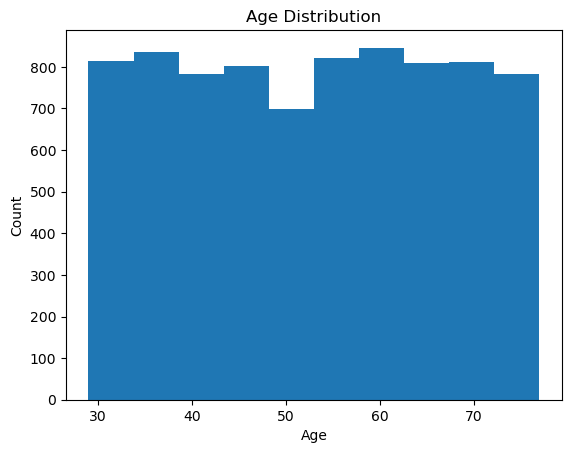

In [44]:
plt.figure()
plt.hist(df['AGE'])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

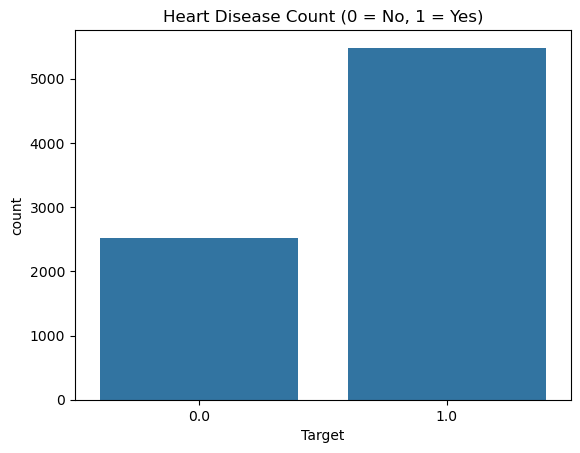

In [45]:
plt.figure()
sns.countplot(x='Target', data=df)
plt.title("Heart Disease Count (0 = No, 1 = Yes)")
plt.show()

In [46]:
# 5. ENCODE CATEGORICAL DATA

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])


In [47]:
# 6. SPLIT FEATURES & TARGET

X = df.drop('Target', axis=1)
y = df['Target']

In [48]:
# 7. FEATURE SCALING

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

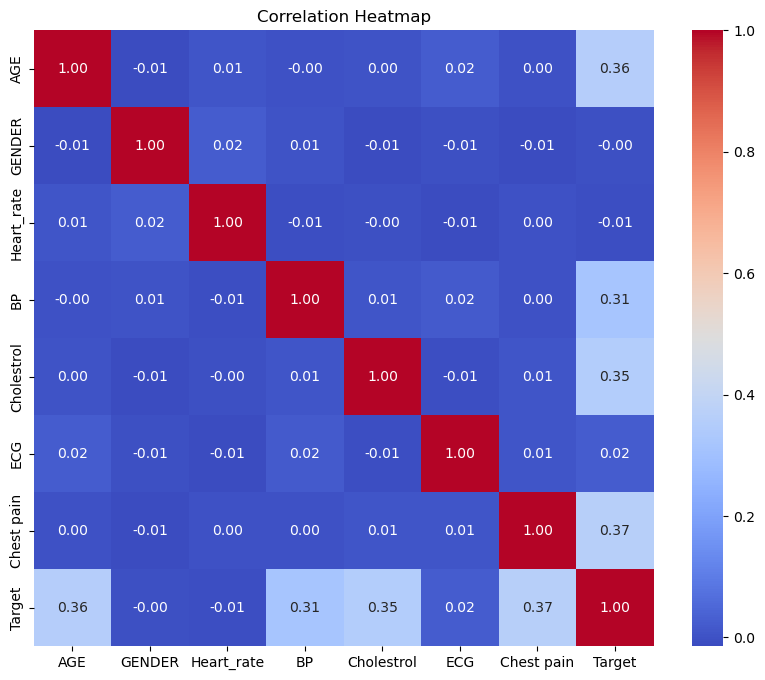

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drop unnecessary column
df = df.drop(columns=['PATIENT_ID'])

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

In [50]:
# 8. TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

In [51]:
#  LOGISTIC REGRESSION

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)


In [54]:
#  KNN

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)


In [55]:
# Logistic Regression Results

print("=== Logistic Regression ===")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))



# KNN Results

print("\n=== KNN ===")
print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall   :", recall_score(y_test, y_pred_knn))
print("F1 Score :", f1_score(y_test, y_pred_knn))

=== Logistic Regression ===
Accuracy : 0.863125
Precision: 0.8919642857142858
Recall   : 0.910665451230629
F1 Score : 0.9012178619756428

=== KNN ===
Accuracy : 0.92
Precision: 0.929140832595217
Recall   : 0.9562443026435734
F1 Score : 0.9424977538185085
